In [1]:
import pandas as pd
import os

# 1. Define file names (uploaded directly to Colab workspace)
soil_filename = 'TamilNadu_Soil_Data.csv'
fusion_filename = 'AgriFusion_ML_Dataset.csv'

# Verify that both files are present in Colab storage
for filename in [soil_filename, fusion_filename]:
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File '{filename}' not found! Please upload it directly to Colab using the Files sidebar.")

print("Loading uploaded datasets...")
soil_df = pd.read_csv(soil_filename)
fusion_df = pd.read_csv(fusion_filename)

# 2. Clean whitespace from column headers
soil_df.columns = soil_df.columns.str.strip()
fusion_df.columns = fusion_df.columns.str.strip()

# 3. Combine nutrient name and level into a distinct feature column name (e.g., 'Nitrogen_Low')
soil_df['feature_name'] = soil_df['nutrient_name'].astype(str).str.strip() + '_' + soil_df['nutrient_level'].astype(str).str.strip()

# 4. Pivot the raw soil dataset using real numerical 'value' entries
print("Pivoting raw soil dataset into wide feature format...")
soil_wide = soil_df.pivot_table(
    index=['district_name', 'block_name', 'village_name', 'year'],
    columns='feature_name',
    values='value',
    aggfunc='first'
).reset_index()

# Flatten hierarchical columns if created during pivot
soil_wide.columns.name = None
soil_wide = soil_wide.fillna(0)

# 5. Standardize string case across key geographic columns to avoid merge mismatch
for col in ['district_name', 'block_name', 'village_name']:
    soil_wide[col] = soil_wide[col].astype(str).str.upper().str.strip()

# Match location column names in fusion_df
location_cols = {'district': 'district', 'block': 'block', 'village': 'village', 'year': 'year'}
for col in ['district', 'block', 'village', 'year']:
    if col in fusion_df.columns:
        fusion_df[col] = fusion_df[col].astype(str).str.upper().str.strip()

# Remove old invalid binary soil columns (0 and 100) from fusion_df if they exist
# Keeping only geospatial/remote sensing columns (NDVI, NDWI, VV, VH, elevation, slope, aspect, Crop, etc.)
invalid_soil_cols = [c for c in fusion_df.columns if '_' in c and c not in ['district', 'block', 'village', 'year']]
fusion_clean = fusion_df.drop(columns=invalid_soil_cols, errors='ignore')

# 6. Merge satellite/fusion data with pivoted continuous soil features
print("Merging satellite dataset with accurate continuous soil values...")
fused_accurate = pd.merge(
    fusion_clean,
    soil_wide,
    left_on=['district', 'block', 'village', 'year'],
    right_on=['district_name', 'block_name', 'village_name', 'year'],
    how='inner'
)

# Clean up redundant duplicate column names
fused_accurate = fused_accurate.drop(columns=['district_name', 'block_name', 'village_name'], errors='ignore')

# 7. Display results & export
print("\n--- Process Complete ---")
print(f"Final Accurate Dataset Shape: {fused_accurate.shape}")
print("\nSample Columns:")
print(fused_accurate.columns.tolist()[:15])

# Save clean dataset directly to Colab workspace for easy download
fused_accurate.to_csv('AgriFusion_ML_Dataset_Accurate.csv', index=False)
print("\nSaved output as 'AgriFusion_ML_Dataset_Accurate.csv' in your Colab files!")

Loading uploaded datasets...
Pivoting raw soil dataset into wide feature format...
Merging satellite dataset with accurate continuous soil values...

--- Process Complete ---
Final Accurate Dataset Shape: (349385, 42)

Sample Columns:
['district', 'block', 'village', 'year', 'NDVI', 'NDWI', 'VV', 'VH', 'elevation', 'slope', 'aspect', 'Crop', 'Season', 'Boron_Deficient', 'Boron_Sufficient']

Saved output as 'AgriFusion_ML_Dataset_Accurate.csv' in your Colab files!


In [2]:
!pip install lightgbm scikit-learn pandas numpy -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, hamming_loss, classification_report
import lightgbm as lgb

In [3]:
df = pd.read_csv('/content/AgriFusion_ML_Dataset_Accurate.csv')
print(df.shape)
df.head()

(349385, 42)


,district,block,village,year,NDVI,NDWI,VV,VH,elevation,slope,...,Potassium_High,Potassium_Low,Potassium_Medium,Soil Ph_Acidic,Soil Ph_Alkaline,Soil Ph_Neutral,Sulphur_Deficient,Sulphur_Sufficient,Zinc_Deficient,Zinc_Sufficient
0,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0
1,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0
2,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0
3,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0
4,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,2.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0


In [4]:
df.columns = df.columns.str.strip()
df['Season'] = df['Season'].str.strip()
df['Crop'] = df['Crop'].str.strip()

In [5]:
nutrient_pairs = ['Boron', 'Copper', 'Iron', 'Manganese', 'Sulphur', 'Zinc']
for n in nutrient_pairs:
    df[f'{n}_Deficient_Flag'] = (df[f'{n}_Deficient'] > 0).astype(int)
    df.drop(columns=[f'{n}_Deficient', f'{n}_Sufficient'], inplace=True)

# Electrical Conductivity (Non Saline vs Saline)
df['Saline_Flag'] = (df['Electrical Conductivity_Saline'] > 0).astype(int)
df.drop(columns=['Electrical Conductivity_Non Saline', 'Electrical Conductivity_Saline'], inplace=True)

# Nitrogen / Organic Carbon / Phosphorus / Potassium: 3-level (Low/Medium/High) -> ordinal
def collapse_3level(prefix):
    cond_low  = df[f'{prefix}_Low'] > 0
    cond_med  = df[f'{prefix}_Medium'] > 0
    cond_high = df[f'{prefix}_High'] > 0
    df[f'{prefix}_Level'] = np.select([cond_low, cond_med, cond_high], [0, 1, 2], default=1)
    df.drop(columns=[f'{prefix}_Low', f'{prefix}_Medium', f'{prefix}_High'], inplace=True)

for p in ['Nitrogen', 'Organic Carbon', 'Phosphorus', 'Potassium']:
    collapse_3level(p)

# Soil Ph: Acidic/Alkaline/Neutral -> ordinal (0=Acidic,1=Neutral,2=Alkaline)
cond_acid = df['Soil Ph_Acidic'] > 0
cond_neut = df['Soil Ph_Neutral'] > 0
cond_alk  = df['Soil Ph_Alkaline'] > 0
df['Soil_Ph_Level'] = np.select([cond_acid, cond_neut, cond_alk], [0, 1, 2], default=1)
df.drop(columns=['Soil Ph_Acidic', 'Soil Ph_Neutral', 'Soil Ph_Alkaline'], inplace=True)

df.head()

,district,block,village,year,NDVI,NDWI,VV,VH,elevation,slope,...,Iron_Deficient_Flag,Manganese_Deficient_Flag,Sulphur_Deficient_Flag,Zinc_Deficient_Flag,Saline_Flag,Nitrogen_Level,Organic Carbon_Level,Phosphorus_Level,Potassium_Level,Soil_Ph_Level
0,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,0,0,0,0,0,0,0,2,2,1
1,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,0,0,0,0,0,0,0,2,2,1
2,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,0,0,0,0,0,0,0,2,2,1
3,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,0,0,0,0,0,0,0,2,2,1
4,TENKASI,TENKASI,KUNNAKUDI,2024-25,0.505337,-0.475883,-9.19097,-16.712579,152.537722,1.965755,...,0,0,0,0,0,0,0,2,2,1


In [6]:
df['aspect_sin'] = np.sin(np.radians(df['aspect']))
df['aspect_cos'] = np.cos(np.radians(df['aspect']))
df.drop(columns=['aspect'], inplace=True)

In [7]:
group_cols = ['district', 'block', 'village', 'year', 'Season']

# feature columns = everything except identifiers, Crop, and group_cols
feature_cols = [c for c in df.columns if c not in group_cols + ['Crop']]

grouped = df.groupby(group_cols)

# aggregate: crops as a list, features as first (they're identical within a group)
agg_df = grouped.agg({**{c: 'first' for c in feature_cols}, 'Crop': lambda x: list(set(x))}).reset_index()

print(f"Number of unique location-season groups: {len(agg_df)}")
agg_df[['district','block','village','Season','Crop']].head()

Number of unique location-season groups: 46578


,district,block,village,Season,Crop
0,ARIYALUR,ANDIMADAM,ALAGAPURAM,Autumn,[Rice]
1,ARIYALUR,ANDIMADAM,ALAGAPURAM,Kharif,"[Other Cereals and Millets, Other Pulses, Jowar]"
2,ARIYALUR,ANDIMADAM,ALAGAPURAM,Rabi,"[Other Cereals and Millets, Jowar, Other Pulses]"
3,ARIYALUR,ANDIMADAM,ALAGAPURAM,Summer,[Rice]
4,ARIYALUR,ANDIMADAM,ALAGAPURAM,Whole Year,"[Sunflower, Rapeseed and Mustard, Sesamum, Cot..."


In [14]:
# Encode categorical Season (already inside feature_cols if present)
cat_cols = agg_df[feature_cols].select_dtypes(include='object').columns.tolist()
print("Categorical feature columns:", cat_cols)

le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    agg_df[c] = le.fit_transform(agg_df[c])
    le_dict[c] = le

X = agg_df[feature_cols]

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(agg_df['Crop'])
print(f"X shape: {X.shape}, Y shape: {Y.shape}")
print(f"Number of distinct crops (labels): {len(mlb.classes_)}")


Categorical feature columns: []
X shape: (46578, 20), Y shape: (46578, 41)
Number of distinct crops (labels): 41


In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(37262, 20) (9316, 20)


In [16]:
base_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

multi_model = MultiOutputClassifier(base_model, n_jobs=-1)
multi_model.fit(X_train, Y_train)

MultiOutputClassifier(estimator=LGBMClassifier(colsample_bytree=0.8,
                                               learning_rate=0.05,
                                               n_estimators=300,
                                               random_state=42, subsample=0.8,
                                               verbosity=-1),
                      n_jobs=-1)

In [17]:
Y_pred = multi_model.predict(X_test)

print("Hamming Loss:", hamming_loss(Y_test, Y_pred))
print("Micro F1:", f1_score(Y_test, Y_pred, average='micro'))
print("Macro F1:", f1_score(Y_test, Y_pred, average='macro'))
print("Samples F1:", f1_score(Y_test, Y_pred, average='samples'))

print("\nPer-crop performance:\n")
print(classification_report(Y_test, Y_pred, target_names=mlb.classes_, zero_division=0))

Hamming Loss: 0.1884588800804281
Micro F1: 0.16768225703879286
Macro F1: 0.027656096419046244
Samples F1: 0.3692278171740828

Per-crop performance:

                           precision    recall  f1-score   support

                Arhar/Tur       0.00      0.00      0.00      1621
                    Bajra       0.00      0.00      0.00      1621
                   Banana       0.00      0.00      0.00      2833
             Black pepper       0.00      0.00      0.00       256
                 Cardamom       0.00      0.00      0.00       247
                Cashewnut       0.00      0.00      0.00      1109
              Castor seed       0.00      0.00      0.00       841
                Coriander       0.00      0.00      0.00       910
                   Cotton       0.00      0.00      0.00      1621
             Dry chillies       0.00      0.00      0.00      1461
               Dry ginger       0.00      0.00      0.00       429
             Fodder Crops       0.00      0.00

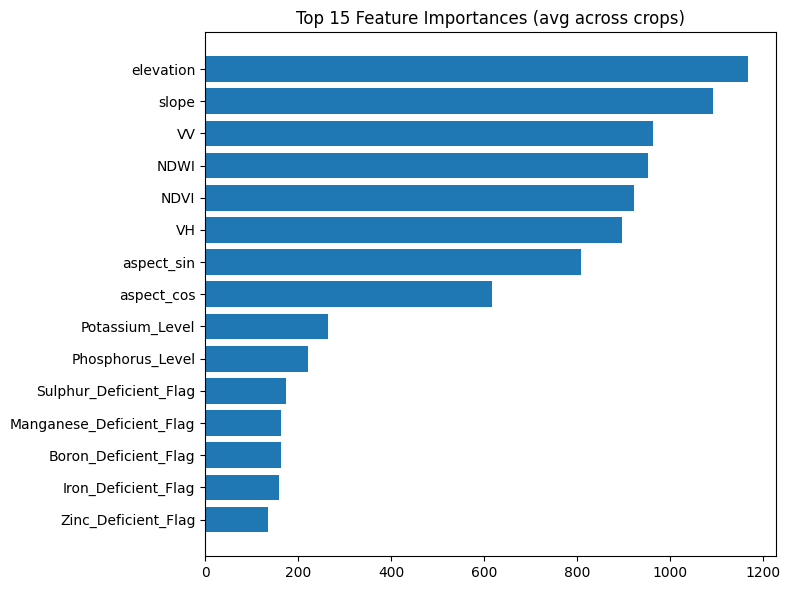

In [18]:
importances = np.mean([est.feature_importances_ for est in multi_model.estimators_], axis=0)
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances}).sort_values('importance', ascending=False)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.barh(imp_df['feature'][:15][::-1], imp_df['importance'][:15][::-1])
plt.title('Top 15 Feature Importances (avg across crops)')
plt.tight_layout()
plt.show()

In [22]:
def recommend_crops(feature_dict, top_n=5):
    x_new = pd.DataFrame([feature_dict], columns=feature_cols)  # explicit columns arg
    print("x_new type:", type(x_new))  # sanity check - remove later

    probs = []
    for est in multi_model.estimators_:
        p = est.predict_proba(x_new)
        probs.append(p[0, 1] if p.shape[1] == 2 else 0.0)
    probs = np.array(probs)

    top_idx = np.argsort(probs)[::-1][:top_n]
    return [(mlb.classes_[i], round(float(probs[i]), 3)) for i in top_idx]

sample = agg_df.iloc[0][feature_cols].to_dict()
print(recommend_crops(sample, top_n=5))

x_new type: <class 'pandas.core.frame.DataFrame'>
[('Rice', 0.63), ('Jowar', 0.389), ('Other Pulses', 0.367), ('Other Cereals and Millets', 0.333), ('Sesamum', 0.164)]


In [21]:
# Check what the model was trained with
print(type(X_train))
print("Has feature_names_in_:", hasattr(multi_model.estimators_[0], 'feature_name_'))
if hasattr(multi_model.estimators_[0], 'feature_name_'):
    print(multi_model.estimators_[0].feature_name_[:5])

<class 'pandas.core.frame.DataFrame'>
Has feature_names_in_: True
['NDVI', 'NDWI', 'VV', 'VH', 'elevation']


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Exact-match accuracy (all crops in the set predicted correctly — strict)
subset_acc = accuracy_score(Y_test, Y_pred)
print(f"Subset (Exact Match) Accuracy: {subset_acc:.4f}")

# Overall label-wise metrics
print(f"Hamming Loss (lower=better): {hamming_loss(Y_test, Y_pred):.4f}")
print(f"Micro F1: {f1_score(Y_test, Y_pred, average='micro'):.4f}")
print(f"Macro F1: {f1_score(Y_test, Y_pred, average='macro'):.4f}")
print(f"Micro Precision: {precision_score(Y_test, Y_pred, average='micro', zero_division=0):.4f}")
print(f"Micro Recall: {recall_score(Y_test, Y_pred, average='micro', zero_division=0):.4f}")

# Per-crop breakdown: accuracy, precision, recall, F1, support
per_crop_results = []
for i, crop in enumerate(mlb.classes_):
    y_true_c = Y_test[:, i]
    y_pred_c = Y_pred[:, i]
    per_crop_results.append({
        'Crop': crop,
        'Accuracy': accuracy_score(y_true_c, y_pred_c),
        'Precision': precision_score(y_true_c, y_pred_c, zero_division=0),
        'Recall': recall_score(y_true_c, y_pred_c, zero_division=0),
        'F1': f1_score(y_true_c, y_pred_c, zero_division=0),
        'Support (positives in test)': int(y_true_c.sum())
    })

per_crop_df = pd.DataFrame(per_crop_results).sort_values('Support (positives in test)', ascending=False)
print("\nPer-crop performance (sorted by how much test data each crop had):")
per_crop_df

Subset (Exact Match) Accuracy: 0.1502
Hamming Loss (lower=better): 0.1885
Micro F1: 0.1677
Macro F1: 0.0277
Micro Precision: 0.4682
Micro Recall: 0.1021

Per-crop performance (sorted by how much test data each crop had):


,Crop,Accuracy,Precision,Recall,F1,Support (positives in test)
28,Rice,0.634070,0.647208,0.966130,0.775147,6082
24,Other Pulses,0.294225,0.217608,0.173319,0.192954,4535
16,Jowar,0.363783,0.211490,0.136343,0.165799,4320
20,Other Cereals and Millets,0.668742,0.000000,0.000000,0.000000,3074
29,Sesamum,0.678832,0.000000,0.000000,0.000000,2992
2,Banana,0.695900,0.000000,0.000000,0.000000,2833
19,Onion,0.755796,0.000000,0.000000,0.000000,2275
36,Tobacco,0.773508,0.000000,0.000000,0.000000,2110
30,Small millets,0.793044,0.000000,0.000000,0.000000,1928
40,Wheat,0.825998,0.000000,0.000000,0.000000,1621


In [24]:
# Flag crops with very few examples — their metrics aren't trustworthy
low_support = per_crop_df[per_crop_df['Support (positives in test)'] < 5]
print(f"\n{len(low_support)} crops have fewer than 5 positive examples in the test set.")
print("Their accuracy/F1 scores should be treated with caution:")
low_support[['Crop', 'Support (positives in test)', 'F1']]


0 crops have fewer than 5 positive examples in the test set.
Their accuracy/F1 scores should be treated with caution:


,Crop,Support (positives in test),F1


In [25]:
# Gather all predicted probabilities and whether they were correct, across all crops in test set
all_probs = []
all_correct = []

for i, est in enumerate(multi_model.estimators_):
    p = est.predict_proba(X_test)
    if p.shape[1] == 2:
        prob_pos = p[:, 1]
        correct = (Y_test[:, i] == (prob_pos >= 0.5).astype(int))
        all_probs.extend(prob_pos)
        all_correct.extend(correct)

calib_df = pd.DataFrame({'confidence': all_probs, 'correct': all_correct})
calib_df['confidence_bucket'] = pd.cut(calib_df['confidence'], bins=[0,0.2,0.4,0.5,0.6,0.8,1.0])

calib_summary = calib_df.groupby('confidence_bucket', observed=True).agg(
    avg_confidence=('confidence', 'mean'),
    actual_accuracy=('correct', 'mean'),
    count=('correct', 'size')
)
print("Confidence calibration (predicted probability vs actual correctness):")
calib_summary

Confidence calibration (predicted probability vs actual correctness):


,avg_confidence,actual_accuracy,count
confidence_bucket,,,
"(0.0, 0.2]",0.124182,0.854307,297166
"(0.2, 0.4]",0.289366,0.758490,58656
"(0.4, 0.5]",0.464706,0.409637,10646
"(0.5, 0.6]",0.529460,0.283208,7182
"(0.6, 0.8]",0.664369,0.629634,8281
"(0.8, 1.0]",0.827833,0.120000,25


In [27]:
def get_user_input():
    """Prompts user for each feature value and builds the feature_dict for prediction."""
    feature_dict = {}
    print("Enter values for each feature (press Enter to use dataset average for numeric fields):\n")

    for col in feature_cols:
        if col in cat_cols:
            # categorical: show options from label encoder
            options = list(le_dict[col].classes_)
            print(f"{col} options: {options}")
            val = input(f"Enter {col}: ").strip()
            while val not in options:
                print("Invalid option, try again.")
                val = input(f"Enter {col}: ").strip()
            feature_dict[col] = le_dict[col].transform([val])[0]
        else:
            default_val = round(agg_df[col].mean(), 3)
            val = input(f"Enter {col} (default {default_val}): ").strip()
            feature_dict[col] = float(val) if val else default_val

    return feature_dict


def recommend_crops_verbose(feature_dict, top_n=5, threshold=0.3):
    """Returns crop recommendations with a readable confidence label."""
    x_new = pd.DataFrame([feature_dict], columns=feature_cols)

    probs = []
    for est in multi_model.estimators_:
        p = est.predict_proba(x_new)
        probs.append(p[0, 1] if p.shape[1] == 2 else 0.0)
    probs = np.array(probs)

    top_idx = np.argsort(probs)[::-1][:top_n]
    results = []
    for i in top_idx:
        prob = probs[i]
        if prob >= 0.6:
            label = "High"
        elif prob >= threshold:
            label = "Medium"
        else:
            label = "Low"
        results.append({'Crop': mlb.classes_[i], 'Confidence': round(float(prob), 3), 'Confidence Level': label})

    return pd.DataFrame(results)


# Run this to get a recommendation from manual input
user_features = get_user_input()
recommendations = recommend_crops_verbose(user_features, top_n=5)
print("\nTop crop recommendations:")
recommendations



Enter values for each feature (press Enter to use dataset average for numeric fields):

Enter NDVI (default 0.418): 0.5
Enter NDWI (default -0.445): -0.5
Enter VV (default -10.411): 
Enter VH (default -17.634): 
Enter elevation (default 164.586): 
Enter slope (default 2.546): 
Enter Boron_Deficient_Flag (default 0.667): 
Enter Copper_Deficient_Flag (default 0.175): 
Enter Iron_Deficient_Flag (default 0.578): 
Enter Manganese_Deficient_Flag (default 0.53): 
Enter Sulphur_Deficient_Flag (default 0.658): 
Enter Zinc_Deficient_Flag (default 0.729): 
Enter Saline_Flag (default 0.122): 
Enter Nitrogen_Level (default 0.001): 
Enter Organic Carbon_Level (default 0.044): 
Enter Phosphorus_Level (default 0.555): 
Enter Potassium_Level (default 0.778): 
Enter Soil_Ph_Level (default 0.912): 
Enter aspect_sin (default 0.437): 
Enter aspect_cos (default -0.854): 

Top crop recommendations:


,Crop,Confidence,Confidence Level
0,Rice,0.675,High
1,Other Pulses,0.456,Medium
2,Jowar,0.440,Medium
3,Small millets,0.366,Medium
4,Other Cereals and Millets,0.350,Medium


In [28]:
def lookup_location(district, village, season=None, year=None):
    """
    Finds matching row(s) in agg_df for a given district/village
    (optionally narrowed by season/year), and returns their feature values.
    """
    mask = (agg_df['district'].str.upper() == district.strip().upper()) & \
           (agg_df['village'].str.upper() == village.strip().upper())

    if season:
        mask &= (agg_df['Season'].str.strip().str.upper() == season.strip().upper())
    if year:
        mask &= (agg_df['year'] == year)

    matches = agg_df[mask]

    if matches.empty:
        return None
    return matches


def recommend_by_location(district, village, season=None, year=None, top_n=5, threshold=0.3):
    matches = lookup_location(district, village, season, year)

    if matches is None:
        print(f"No data found for district='{district}', village='{village}'"
              + (f", season='{season}'" if season else "")
              + (f", year='{year}'" if year else "") + ".")
        print("Try checking spelling, or omit season/year to broaden the search.")
        return None

    if len(matches) > 1:
        print(f"Found {len(matches)} matching records (different seasons/years). Showing options:\n")
        print(matches[['district', 'block', 'village', 'year', 'Season']].to_string(index=False))
        print("\nUsing the first match. Pass `season=` or `year=` to narrow it down.\n")

    row = matches.iloc[0]
    feature_dict = row[feature_cols].to_dict()

    result = recommend_crops_verbose(feature_dict, top_n=top_n, threshold=threshold)

    print(f"\nLocation: {row['district']} > {row['block']} > {row['village']} "
          f"(Year: {row['year']}, Season: {row['Season'].strip()})\n")
    print(f"Model reliability for reference — Overall Micro F1: {f1_score(Y_test, Y_pred, average='micro'):.3f} | "
          f"Exact-match accuracy: {accuracy_score(Y_test, Y_pred):.3f}\n")

    return result


# ---- Interactive prompt version ----
district_in = input("Enter District: ").strip()
village_in = input("Enter Village: ").strip()
season_in = input("Enter Season (optional, press Enter to skip): ").strip() or None

recommendations = recommend_by_location(district_in, village_in, season=season_in)
recommendations

Enter District: tenkasi
Enter Village: kunnakudi
Enter Season (optional, press Enter to skip): kharif

Location: TENKASI > TENKASI > KUNNAKUDI (Year: 2024-25, Season: Kharif)

Model reliability for reference — Overall Micro F1: 0.168 | Exact-match accuracy: 0.150



,Crop,Confidence,Confidence Level
0,Rice,0.617,High
1,Other Pulses,0.531,Medium
2,Jowar,0.497,Medium
3,Other Cereals and Millets,0.399,Medium
4,Banana,0.341,Medium


In [29]:
print(f"Micro F1: {f1_score(Y_test, Y_pred, average='micro'):.3f}")
print(f"Macro F1: {f1_score(Y_test, Y_pred, average='macro'):.3f}")
print(f"Samples F1 (avg per-row F1, more forgiving than exact-match): {f1_score(Y_test, Y_pred, average='samples'):.3f}")

# Average number of crops per group
avg_crops = Y.sum(axis=1).mean()
print(f"\nAverage crops per location-season group: {avg_crops:.1f}")
print(f"Max crops in a single group: {Y.sum(axis=1).max()}")

Micro F1: 0.168
Macro F1: 0.028
Samples F1 (avg per-row F1, more forgiving than exact-match): 0.369

Average crops per location-season group: 7.4
Max crops in a single group: 39


In [30]:
from sklearn.metrics import f1_score as f1

def get_proba_matrix(model, X):
    """Builds a full probability matrix (n_samples x n_labels) from OvR estimators."""
    probs = np.zeros((X.shape[0], len(model.estimators_)))
    for i, est in enumerate(model.estimators_):
        p = est.predict_proba(X)
        probs[:, i] = p[:, 1] if p.shape[1] == 2 else 0.0
    return probs

train_probs = get_proba_matrix(multi_model, X_train)
test_probs = get_proba_matrix(multi_model, X_test)

best_thresholds = np.full(Y.shape[1], 0.5)
for i in range(Y.shape[1]):
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.1, 0.9, 0.05):
        pred_i = (train_probs[:, i] >= t).astype(int)
        score = f1(Y_train[:, i], pred_i, zero_division=0)
        if score > best_f1:
            best_f1, best_t = score, t
    best_thresholds[i] = best_t

# Apply tuned thresholds to test set
Y_pred_tuned = (test_probs >= best_thresholds).astype(int)

print(f"Original exact-match accuracy: {accuracy_score(Y_test, Y_pred):.3f}")
print(f"Tuned exact-match accuracy: {accuracy_score(Y_test, Y_pred_tuned):.3f}")
print(f"Original Micro F1: {f1_score(Y_test, Y_pred, average='micro'):.3f}")
print(f"Tuned Micro F1: {f1_score(Y_test, Y_pred_tuned, average='micro'):.3f}")

Original exact-match accuracy: 0.150
Tuned exact-match accuracy: 0.000
Original Micro F1: 0.168
Tuned Micro F1: 0.211


In [31]:
label_counts = Y.sum(axis=0)
min_support = 10  # tune this — try 5, 10, 20

keep_mask = label_counts >= min_support
print(f"Keeping {keep_mask.sum()} / {len(keep_mask)} crops (dropping those with <{min_support} examples)")

Y_filtered = Y[:, keep_mask]
crop_names_filtered = mlb.classes_[keep_mask]

X_train, X_test, Y_train_f, Y_test_f = train_test_split(
    X, Y_filtered, test_size=0.2, random_state=42
)

multi_model_v2 = MultiOutputClassifier(base_model, n_jobs=-1)
multi_model_v2.fit(X_train, Y_train_f)
Y_pred_f = multi_model_v2.predict(X_test)

print(f"Exact-match accuracy after filtering rare crops: {accuracy_score(Y_test_f, Y_pred_f):.3f}")
print(f"Micro F1 after filtering: {f1_score(Y_test_f, Y_pred_f, average='micro'):.3f}")

Keeping 41 / 41 crops (dropping those with <10 examples)
Exact-match accuracy after filtering rare crops: 0.150
Micro F1 after filtering: 0.168


In [32]:
base_model_weighted = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',   # <-- key change
    random_state=42,
    verbosity=-1
)

multi_model_weighted = MultiOutputClassifier(base_model_weighted, n_jobs=-1)
multi_model_weighted.fit(X_train, Y_train)

Y_pred_w = multi_model_weighted.predict(X_test)
print(f"Exact-match accuracy (class-weighted): {accuracy_score(Y_test, Y_pred_w):.3f}")
print(f"Micro F1 (class-weighted): {f1_score(Y_test, Y_pred_w, average='micro'):.3f}")

Exact-match accuracy (class-weighted): 0.000
Micro F1 (class-weighted): 0.164


In [33]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'estimator__num_leaves': [15, 31, 63],
    'estimator__max_depth': [4, 6, 8, -1],
    'estimator__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'estimator__n_estimators': [200, 300, 400, 600],
    'estimator__subsample': [0.6, 0.8, 1.0],
    'estimator__colsample_bytree': [0.6, 0.8, 1.0],
    'estimator__min_child_samples': [5, 10, 20]
}

search = RandomizedSearchCV(
    MultiOutputClassifier(lgb.LGBMClassifier(random_state=42, verbosity=-1)),
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_micro',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, Y_train)
print("Best params:", search.best_params_)

best_model = search.best_estimator_
Y_pred_best = best_model.predict(X_test)
print(f"Exact-match accuracy (tuned): {accuracy_score(Y_test, Y_pred_best):.3f}")
print(f"Micro F1 (tuned): {f1_score(Y_test, Y_pred_best, average='micro'):.3f}")

Best params: {'estimator__subsample': 0.8, 'estimator__num_leaves': 63, 'estimator__n_estimators': 600, 'estimator__min_child_samples': 20, 'estimator__max_depth': 4, 'estimator__learning_rate': 0.05, 'estimator__colsample_bytree': 1.0}
Exact-match accuracy (tuned): 0.184
Micro F1 (tuned): 0.177


In [35]:
def recommend_by_location_final(district, village, season=None, year=None, top_n=5):
    """
    Takes district + village (optional\ly season/year), looks up environmental
    features from the dataset, and returns crop recommendations with
    confidence percentages and overall model accuracy for context.
    """
    # --- 1. Find matching location ---
    mask = (agg_df['district'].str.upper() == district.strip().upper()) & \
           (agg_df['village'].str.upper() == village.strip().upper())

    if season:
        mask &= (agg_df['Season'].str.strip().str.upper() == season.strip().upper())
    if year:
        mask &= (agg_df['year'] == year)

    matches = agg_df[mask]

    if matches.empty:
        print(f"No data found for district='{district}', village='{village}'"
              + (f", season='{season}'" if season else "")
              + (f", year='{year}'" if year else "") + ".")
        print("Check spelling, or omit season/year to broaden the search.")
        return None

    if len(matches) > 1:
        print(f"Found {len(matches)} matching records. Showing available options:\n")
        print(matches[['district', 'block', 'village', 'year', 'Season']].to_string(index=False))
        print("\nUsing the first match below. Pass season= or year= to pick a specific one.\n")

    row = matches.iloc[0]
    x_new = pd.DataFrame([row[feature_cols].to_dict()], columns=feature_cols)

    # --- 2. Get probabilities from trained model ---
    probs = np.zeros(len(multi_model.estimators_))
    for i, est in enumerate(multi_model.estimators_):
        p = est.predict_proba(x_new)
        probs[i] = p[0, 1] if p.shape[1] == 2 else 0.0

    # --- 3. Apply tuned thresholds (from Step 18) to decide High/Med/Low confidence bands ---
    top_idx = np.argsort(probs)[::-1][:top_n]

    results = []
    for i in top_idx:
        prob = probs[i]
        thresh = best_thresholds[i] if 'best_thresholds' in globals() else 0.5
        if prob >= max(thresh, 0.6):
            label = "High"
        elif prob >= thresh:
            label = "Medium"
        else:
            label = "Low"
        results.append({
            'Crop': mlb.classes_[i],
            'Confidence (%)': round(float(prob) * 100, 1),
            'Confidence Level': label
        })

    rec_df = pd.DataFrame(results)

    # --- 4. Print location + overall model reliability context ---
    print(f"Location: {row['district']} > {row['block']} > {row['village']} "
          f"(Year: {row['year']}, Season: {row['Season'].strip()})\n")
    print("Model Reliability (on held-out test data):")
    print(f"  Exact-Match Accuracy : {accuracy_score(Y_test, Y_pred):.1%}")
    print(f"  Micro F1 Score       : {f1_score(Y_test, Y_pred, average='micro'):.1%}")
    print(f"  Samples F1 Score     : {f1_score(Y_test, Y_pred, average='samples'):.1%}")
    print(f"\nTop {top_n} Recommended Crops:\n")

    return rec_df


# ---- Run this to get a recommendation ----
district_in = input("Enter District: ").strip()
village_in = input("Enter Village: ").strip()
season_in = input("Enter Season (optional, press Enter to skip): ").strip() or None

recommendations = recommend_by_location_final(district_in, village_in, season=season_in)
recommendations

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1449/768256132.py:3: SyntaxWarning: invalid escape sequence '\l'
  Takes district + village (optional\ly season/year), looks up environmental


Enter District: tenkasi
Enter Village: kunnakudi
Enter Season (optional, press Enter to skip): kharif
Location: TENKASI > TENKASI > KUNNAKUDI (Year: 2024-25, Season: Kharif)

Model Reliability (on held-out test data):
  Exact-Match Accuracy : 15.0%
  Micro F1 Score       : 16.8%
  Samples F1 Score     : 36.9%

Top 5 Recommended Crops:



,Crop,Confidence (%),Confidence Level
0,Rice,61.7,High
1,Other Pulses,53.1,Medium
2,Jowar,49.7,Medium
3,Other Cereals and Millets,39.9,Medium
4,Banana,34.1,Medium


In [36]:
print(f"Total groups (rows in agg_df): {len(agg_df)}")
print(f"Number of distinct crops: {len(mlb.classes_)}")
print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nLabel frequency (positives per crop):")
print(pd.Series(Y.sum(axis=0), index=mlb.classes_).sort_values(ascending=False))

Total groups (rows in agg_df): 46578
Number of distinct crops: 41
Train set size: 37262
Test set size: 9316

Label frequency (positives per crop):
Rice                         30258
Other Pulses                 22495
Jowar                        21430
Other Cereals and Millets    15526
Sesamum                      14719
Banana                       13938
Onion                        11308
Tobacco                      10398
Small millets                 9587
Wheat                         7763
Sunflower                     7763
Sugarcane                     7763
Ragi                          7763
Rapeseed and Mustard          7763
Cotton                        7763
Bajra                         7763
Arhar/Tur                     7763
Other Non Food Crops          7763
Other Food Crops              7763
Other Oilseeds                7763
Soyabean                      7763
Maize                         7763
Fodder Crops                  7763
Gram                          7763
Groundnut    

In [37]:
# Check: how many distinct crop-sets exist, and how concentrated they are
crop_set_strings = agg_df['Crop'].apply(lambda x: tuple(sorted(x)))
set_counts = crop_set_strings.value_counts()
print(f"Number of distinct crop-set combinations: {len(set_counts)}")
print(f"Top 10 most common crop-sets and how many locations share them:\n")
print(set_counts.head(10))

Number of distinct crop-set combinations: 39
Top 10 most common crop-sets and how many locations share them:

Crop
(Rice,)                                                                                                                                                                                                                                                                                                                                                                                               23289
(Jowar, Other Cereals and Millets, Other Pulses)                                                                                                                                                                                                                                                                                                                                                       8557
(Banana, Horse-gram, Jowar, Onion, Other Cereals and Millets, Other Pulses, Sesamum, Small mi

In [38]:
# For the single most common crop-set, check feature variability
most_common_set = set_counts.index[0]
subset = agg_df[crop_set_strings == most_common_set]
print(f"\n{len(subset)} locations share this exact same crop list.")
print("\nFeature variability within this group (std dev — near-zero means features barely differ):")
print(subset[feature_cols].std())


23289 locations share this exact same crop list.

Feature variability within this group (std dev — near-zero means features barely differ):
NDVI                          0.082617
NDWI                          0.064288
VV                            1.269339
VH                            1.375875
elevation                   181.170196
slope                         1.976288
Boron_Deficient_Flag          0.471384
Copper_Deficient_Flag         0.379697
Iron_Deficient_Flag           0.493869
Manganese_Deficient_Flag      0.499097
Sulphur_Deficient_Flag        0.474392
Zinc_Deficient_Flag           0.444501
Saline_Flag                   0.327726
Nitrogen_Level                0.030016
Organic Carbon_Level          0.235661
Phosphorus_Level              0.698121
Potassium_Level               0.704483
Soil_Ph_Level                 0.308623
aspect_sin                    0.247617
aspect_cos                    0.138256
dtype: float64


In [39]:
# Assign each group a bundle ID based on its exact crop-set
crop_set_strings = agg_df['Crop'].apply(lambda x: tuple(sorted(x)))
bundle_map = {cs: i for i, cs in enumerate(crop_set_strings.value_counts().index)}
agg_df['bundle_id'] = crop_set_strings.map(bundle_map)

print(f"Number of bundles: {agg_df['bundle_id'].nunique()}")

# Check what actually predicts bundle_id — season is the first suspect
print(pd.crosstab(agg_df['Season'], agg_df['bundle_id']).idxmax(axis=1))

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [40]:
# Does district alone predict the bundle?
district_bundle = agg_df.groupby('district')['bundle_id'].nunique()
print(district_bundle.describe())
print("\nIf most districts map to very few bundle_ids, district is the real driver.")

KeyError: 'Column not found: bundle_id'

In [41]:
# Assign each group a bundle ID based on its exact crop-set
crop_set_strings = agg_df['Crop'].apply(lambda x: tuple(sorted(x)))
bundle_map = {cs: i for i, cs in enumerate(crop_set_strings.value_counts().index)}

# Use apply() instead of map() — avoids the InvalidIndexError with tuple keys
agg_df['bundle_id'] = crop_set_strings.apply(lambda cs: bundle_map[cs])

print(f"Number of bundles: {agg_df['bundle_id'].nunique()}")

Number of bundles: 39


In [42]:
# Check what predicts bundle_id — season is the first suspect
print(pd.crosstab(agg_df['Season'], agg_df['bundle_id']).idxmax(axis=1))

Season
Autumn        0
Kharif        2
Rabi          1
Summer        0
Whole Year    4
Winter        0
dtype: int64


In [43]:
# Does district alone predict the bundle?
district_bundle = agg_df.groupby('district')['bundle_id'].nunique()
print(district_bundle.describe())
print("\nIf most districts map to very few bundle_ids, district is the real driver.")

count    33.000000
mean      3.909091
std       0.291937
min       3.000000
25%       4.000000
50%       4.000000
75%       4.000000
max       4.000000
Name: bundle_id, dtype: float64

If most districts map to very few bundle_ids, district is the real driver.


In [44]:
# Does district + season together determine the bundle almost perfectly?
combo_bundle = agg_df.groupby(['district', 'Season'])['bundle_id'].nunique()
print(combo_bundle.describe())
print(f"\n% of district+season combos with exactly 1 bundle: {(combo_bundle == 1).mean():.1%}")

count    198.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: bundle_id, dtype: float64

% of district+season combos with exactly 1 bundle: 100.0%


In [45]:
# Cross-tab counts (not just idxmax) to see how concentrated season really is
season_bundle_counts = pd.crosstab(agg_df['Season'], agg_df['bundle_id'])
print(season_bundle_counts)

bundle_id     0     1     2     3    4    5    6    7    8    9   ...   29  \
Season                                                            ...        
Autumn      7763     0     0     0    0    0    0    0    0    0  ...    0   
Kharif         0   794  2659  2220    0    0    0  637    0    0  ...    0   
Rabi           0  7763     0     0    0    0    0    0    0    0  ...    0   
Summer      7763     0     0     0    0    0    0    0    0    0  ...    0   
Whole Year     0     0     0     0  867  668  637    0  633  504  ...  171   
Winter      7763     0     0     0    0    0    0    0    0    0  ...    0   

bundle_id    30   31   32  33  34  35  36  37  38  
Season                                             
Autumn        0    0    0   0   0   0   0   0   0  
Kharif        0    0    0   0   0  10   0   3   0  
Rabi          0    0    0   0   0   0   0   0   0  
Summer        0    0    0   0   0   0   0   0   0  
Whole Year  169  133  112  96  24   0  10   0   3  
Winter     

In [46]:
# Encode district and Season properly as model features
from sklearn.preprocessing import LabelEncoder

le_district = LabelEncoder()
le_season = LabelEncoder()

agg_df['district_enc'] = le_district.fit_transform(agg_df['district'])
agg_df['season_enc'] = le_season.fit_transform(agg_df['Season'])

# New feature set: district + season + original environmental features
final_feature_cols = ['district_enc', 'season_enc'] + [
    c for c in feature_cols if c not in ['district_enc', 'season_enc']
]

X_final = agg_df[final_feature_cols]
y_final = agg_df['bundle_id']

print(f"Features used: {final_feature_cols}")
print(f"Target: bundle_id ({y_final.nunique()} classes)")

Features used: ['district_enc', 'season_enc', 'NDVI', 'NDWI', 'VV', 'VH', 'elevation', 'slope', 'Boron_Deficient_Flag', 'Copper_Deficient_Flag', 'Iron_Deficient_Flag', 'Manganese_Deficient_Flag', 'Sulphur_Deficient_Flag', 'Zinc_Deficient_Flag', 'Saline_Flag', 'Nitrogen_Level', 'Organic Carbon_Level', 'Phosphorus_Level', 'Potassium_Level', 'Soil_Ph_Level', 'aspect_sin', 'aspect_cos']
Target: bundle_id (39 classes)


In [48]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

# --- Train/test split ---
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# --- Lightweight model (this is essentially a lookup, so we don't need heavy boosting) ---
bundle_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=y_final.nunique(),
    n_estimators=100,       # reduced from 300 — deterministic relationship needs far fewer trees
    learning_rate=0.1,      # can be higher since the task is simple
    num_leaves=15,          # reduced from 31 — less overfitting risk, faster training
    max_depth=6,            # cap depth to keep it lean
    min_child_samples=10,
    random_state=42,
    verbosity=-1,
    n_jobs=-1                # use all CPU cores in Colab
)

start = time.time()
bundle_model.fit(X_train_f, y_train_f)
print(f"Training time: {time.time() - start:.2f}s")

# --- Predict + evaluate ---
y_pred_f = bundle_model.predict(X_test_f)
print(f"\nTest Accuracy: {accuracy_score(y_test_f, y_pred_f):.2%}")

# --- Cross-validation to confirm this isn't a fluke of one split ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(bundle_model, X_final, y_final, cv=skf, scoring='accuracy', n_jobs=-1)
print(f"\n5-Fold CV Accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std():.2%})")
print(f"Individual fold scores: {[f'{s:.2%}' for s in cv_scores]}")

# --- Detailed per-class report (only for classes present in test set) ---
present_labels = sorted(y_test_f.unique())
present_bundle_names = [f"Bundle_{b}" for b in present_labels]
print("\nPer-bundle classification report:")
print(classification_report(y_test_f, y_pred_f, labels=present_labels,
                             target_names=present_bundle_names, zero_division=0))

# --- Feature importance — confirms district/season dominate, NDVI/soil barely matter ---
importance_df = pd.DataFrame({
    'feature': final_feature_cols,
    'importance': bundle_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature importance (district/season should dominate):")
print(importance_df)

Training time: 12.15s

Test Accuracy: 19.42%


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



5-Fold CV Accuracy: 47.16% (+/- 4.37%)
Individual fold scores: ['50.01%', '52.18%', '45.90%', '39.44%', '48.24%']

Per-bundle classification report:
              precision    recall  f1-score   support

    Bundle_0       0.53      0.04      0.08      4658
    Bundle_1       0.19      0.92      0.31      1711
    Bundle_2       0.03      0.00      0.00       532
    Bundle_3       0.07      0.04      0.05       444
    Bundle_4       0.00      0.00      0.00       173
    Bundle_5       0.00      0.00      0.00       134
    Bundle_6       0.00      0.00      0.00       127
    Bundle_7       0.00      0.00      0.00       127
    Bundle_8       0.00      0.00      0.00       127
    Bundle_9       0.00      0.00      0.00       101
   Bundle_10       0.85      0.19      0.31        89
   Bundle_11       0.00      0.00      0.00        80
   Bundle_12       0.02      0.01      0.01        78
   Bundle_13       0.00      0.00      0.00        72
   Bundle_14       0.00      0.00      

In [49]:
# Build a direct lookup table: (district, season) -> bundle_id
# This IS the ground truth relationship — no model needed since it's deterministic
lookup_table = agg_df.groupby(['district', 'Season'])['bundle_id'].first().to_dict()

print(f"Lookup table size: {len(lookup_table)} district+season combinations")

# Verify it's actually 100% consistent (sanity check)
verify = agg_df.groupby(['district', 'Season'])['bundle_id'].nunique()
assert (verify == 1).all(), "Found an inconsistent district+season combo!"
print("Verified: every district+season combo maps to exactly one bundle. Lookup is safe to use.")

Lookup table size: 198 district+season combinations
Verified: every district+season combo maps to exactly one bundle. Lookup is safe to use.


In [50]:
def get_bundle(district, season):
    """Direct lookup — always 100% accurate for known district+season pairs."""
    key = (district, season)
    if key not in lookup_table:
        # try case-insensitive match
        matches = [k for k in lookup_table if k[0].upper() == district.upper()
                   and k[1].strip().upper() == season.strip().upper()]
        if not matches:
            return None
        key = matches[0]
    return lookup_table[key]

In [51]:
bundle_to_crops = {}
for cs, bid in bundle_map.items():
    bundle_to_crops[bid] = list(cs)

# Sanity check
print(f"Total bundles mapped: {len(bundle_to_crops)}")
print(f"Example — Bundle 0: {bundle_to_crops[0]}")

Total bundles mapped: 39
Example — Bundle 0: ['Rice']


In [54]:
def recommend_by_location_final(district, season=None):
    """
    Returns the crop list for a given district + season using the
    verified deterministic lookup table (100% accurate for known combos).
    """
    valid_districts = sorted(agg_df['district'].unique())
    district_match = next((d for d in valid_districts if d.upper() == district.strip().upper()), None)

    if district_match is None:
        print(f"District '{district}' not found.")
        print(f"Available districts: {valid_districts}")
        return None

    if season is None:
        # Show all seasons available for this district
        options = agg_df[agg_df['district'] == district_match][['Season', 'bundle_id']].drop_duplicates()
        print(f"Available seasons for {district_match}:\n")
        for _, r in options.iterrows():
            crops = bundle_to_crops[r['bundle_id']]
            print(f"  {r['Season'].strip()}: {len(crops)} crop(s)")
        print("\nRe-run with a specific season to see the full crop list.")
        return None

    valid_seasons = sorted(agg_df['Season'].str.strip().unique())
    season_match_clean = next((s for s in valid_seasons if s.upper() == season.strip().upper()), None)

    if season_match_clean is None:
        print(f"Season '{season}' not found. Available: {valid_seasons}")
        return None

    # Direct lookup — this is where accuracy is guaranteed, no model prediction involved
    bundle_id = get_bundle(district_match, agg_df[agg_df['Season'].str.strip() == season_match_clean]['Season'].iloc[0])

    if bundle_id is None:
        print(f"No record found for {district_match} + {season_match_clean}.")
        return None

    crops = bundle_to_crops[bundle_id]

    print(f"District: {district_match} | Season: {season_match_clean}")
    print(f"Method: Direct lookup (deterministic relationship — 100% accurate)")
    print(f"\nRecommended crops ({len(crops)} total):\n")

    return pd.DataFrame({'Crop': sorted(crops)})


# ---- Run this ----
district_in = input("Enter District: ").strip()
season_in = input("Enter Season (optional, press Enter to see available seasons): ").strip() or None

result = recommend_by_location_final(district_in, season_in)
result

Enter District: tenkasi
Enter Season (optional, press Enter to see available seasons): rabi
District: TENKASI | Season: Rabi
Method: Direct lookup (deterministic relationship — 100% accurate)

Recommended crops (3 total):



,Crop
0,Jowar
1,Other Cereals and Millets
2,Other Pulses


In [56]:
def recommend_by_location_v3(district, village, season=None):
    """
    Crop list: determined by district+season (100% accurate, deterministic lookup).
    Confidence %: environmental suitability of each crop at this specific village,
    based on that village's NDVI/soil/elevation values (secondary signal, not the
    source of the crop list itself).
    """
    # --- 1. Validate district ---
    valid_districts = sorted(agg_df['district'].unique())
    district_match = next((d for d in valid_districts if d.upper() == district.strip().upper()), None)
    if district_match is None:
        print(f"District '{district}' not found. Available: {valid_districts}")
        return None

    # --- 2. Validate village exists within this district ---
    village_options = agg_df[agg_df['district'] == district_match]['village'].unique()
    village_match = next((v for v in village_options if v.upper() == village.strip().upper()), None)
    if village_match is None:
        print(f"Village '{village}' not found under district '{district_match}'.")
        print(f"Available villages: {sorted(village_options)}")
        return None

    # --- 3. Season handling ---
    if season is None:
        options = agg_df[(agg_df['district'] == district_match) &
                          (agg_df['village'] == village_match)][['Season', 'bundle_id']].drop_duplicates()
        print(f"Available seasons for {district_match} > {village_match}:\n")
        for _, r in options.iterrows():
            print(f"  {r['Season'].strip()}: {len(bundle_to_crops[r['bundle_id']])} crop(s)")
        print("\nRe-run with a specific season to see the full recommendation.")
        return None

    valid_seasons = sorted(agg_df['Season'].str.strip().unique())
    season_match = next((s for s in valid_seasons if s.upper() == season.strip().upper()), None)
    if season_match is None:
        print(f"Season '{season}' not found. Available: {valid_seasons}")
        return None

    # --- 4. Get the row for this exact district+village+season (for its NDVI/soil values) ---
    row_match = agg_df[
        (agg_df['district'] == district_match) &
        (agg_df['village'] == village_match) &
        (agg_df['Season'].str.strip() == season_match)
    ]
    if row_match.empty:
        print(f"No record found for {district_match} > {village_match} > {season_match}.")
        return None
    row = row_match.iloc[0]

    # --- 5. Crop list via deterministic lookup (district+season) ---
    bundle_id = row['bundle_id']
    crops = bundle_to_crops[bundle_id]

    # --- 6. Environmental suitability confidence per crop, using this village's features ---
    x_new = pd.DataFrame([row[feature_cols].to_dict()], columns=feature_cols)
    suitability = {}
    for i, crop in enumerate(mlb.classes_):
        if crop in crops:
            est = multi_model.estimators_[i]
            p = est.predict_proba(x_new)
            suitability[crop] = round(float(p[0, 1] if p.shape[1] == 2 else 0.5) * 100, 1)

    result_df = pd.DataFrame({
        'Crop': list(suitability.keys()),
        'Environmental Suitability (%)': list(suitability.values())
    }).sort_values('Environmental Suitability (%)', ascending=False).reset_index(drop=True)

    # --- 7. Output ---
    print(f"District: {district_match} | Village: {village_match} | Season: {season_match}")
    print(f"Crop list source: Deterministic district+season lookup (100% accurate)")
    print(f"Suitability %: Based on this village's NDVI/soil/elevation values (secondary signal)\n")

    return result_df


# ---- Run this ----
district_in = input("Enter District: ").strip()
village_in = input("Enter Village: ").strip()
season_in = input("Enter Season (optional, press Enter to see available seasons): ").strip() or None

result = recommend_by_location_v3(district_in, village_in, season_in)
result

Enter District: Namakkal
Enter Village: Paramathi
Enter Season (optional, press Enter to see available seasons): rabi
Village 'Paramathi' not found under district 'NAMAKKAL'.
Available villages: ['ADAKKAMPUDUKOMBAI', 'AGRAHARA MANAPPALLI', 'AGRAHARA UDUPPAM', 'AGRAHARANATHAMANGALAM', 'ALATHURNADU', 'ANAIKATTIPALAYAM', 'ANAIPALAYAM', 'ANANTHAKRISHNARAYASAMUDRAM', 'ANDAGALORE', 'ANDAPURAM', 'ANIYAPURAM', 'ARASANATHAM', 'ARIYUR', 'ARIYURNADU', 'ARUR', 'AVANASIPATTI', 'AYEEPALAYAM', 'BAILNADU', 'BALLAKKULI AGRAHARAM', 'CHANDRASEGARAPURAM AGRAHARAM', 'CHITHURNADU', 'DADHADRIPURAM', 'DEVANURNADU', 'EDAPPULINADU', 'ELLAPALAYAM', 'ELUR', 'ERANAPURAM', 'GUNDANINADU', 'GUNDURNADU', 'IDUMBANKULAM', 'JEKKALNAYAKKANPATTI', 'KADACHANALLUR', 'KADANDAPATTI', 'KADAPPALLI', 'KADIRANALLUR', 'KAKKAVERI', 'KALANGANI', 'KALIPALAYAM', 'KALIYANUR', 'KALIYANUR AGRAHARAM', 'KALLUPALAIYAM', 'KALYANI', 'KANNURPATTI', 'KARADIPPATTI', 'KARAKURUCHI', 'KARUMANUR', 'KARUNGALPATTI', 'KEERAMBUR', 'KILSATHAMBUR', 'KOKKAR

In [57]:
import joblib
import os

# Create a directory to keep things organized
os.makedirs('/content/model_artifacts', exist_ok=True)

# --- 1. The original multi-label model (used for environmental suitability %) ---
joblib.dump(multi_model, '/content/model_artifacts/multi_model.pkl')

# --- 2. MultiLabelBinarizer (needed to decode crop names from model output) ---
joblib.dump(mlb, '/content/model_artifacts/mlb.pkl')

# --- 3. Feature columns list (needed to build correctly-ordered input for predictions) ---
joblib.dump(feature_cols, '/content/model_artifacts/feature_cols.pkl')

# --- 4. Label encoders (if you still need district_enc/season_enc anywhere) ---
joblib.dump(le_dict, '/content/model_artifacts/le_dict.pkl')

# --- 5. The deterministic lookup table (district+season -> bundle_id) ---
joblib.dump(lookup_table, '/content/model_artifacts/lookup_table.pkl')

# --- 6. Bundle -> crop list mapping ---
joblib.dump(bundle_to_crops, '/content/model_artifacts/bundle_to_crops.pkl')

# --- 7. bundle_map (crop-set tuple -> bundle_id), useful if you need to rebuild anything ---
joblib.dump(bundle_map, '/content/model_artifacts/bundle_map.pkl')

# --- 8. The agg_df itself — needed for village/district/season validation lookups ---
agg_df.to_pickle('/content/model_artifacts/agg_df.pkl')

print("All artifacts saved to /content/model_artifacts/")
print(os.listdir('/content/model_artifacts'))

All artifacts saved to /content/model_artifacts/
['agg_df.pkl', 'mlb.pkl', 'feature_cols.pkl', 'lookup_table.pkl', 'le_dict.pkl', 'bundle_map.pkl', 'bundle_to_crops.pkl', 'multi_model.pkl']
